In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [ ]:
df = pd.read_csv('/content/banking_transactions.csv')

df.head()

,id,transaction_id,customer_id,transaction_amount,transaction_type,location,device_type,account_balance,transaction_time,is_fraud
0,1,b327f36d-5a4f-4b24-b5b4-75e7d6425a82,CUST1256,4168.01,Online Transfer,Hyderabad,POS Machine,68292.2,2026-04-08 03:09:27,0
1,2,f12c112e-00bf-42c7-a61e-e83f2f1b5384,CUST2264,101386.00,POS Payment,Pune,POS Machine,283040.0,2026-05-12 13:43:07,1
2,3,48aee92c-a309-4f1a-9cb3-60546ce55274,CUST8310,103761.00,UPI Payment,Mumbai,Desktop,214347.0,2026-05-16 08:44:39,1
3,4,ef1b1cbe-1f77-459d-b492-7a529a34159f,CUST8335,45710.80,Online Transfer,Delhi,Desktop,36276.6,2026-03-19 17:14:20,1
4,5,3e38eedc-8e26-4dd8-a329-d6c8348e6bf9,CUST5803,32569.90,Card Payment,Delhi,Mobile,105578.0,2026-05-18 08:56:04,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   transaction_id      5000 non-null   object 
 2   customer_id         5000 non-null   object 
 3   transaction_amount  5000 non-null   float64
 4   transaction_type    5000 non-null   object 
 5   location            5000 non-null   object 
 6   device_type         5000 non-null   object 
 7   account_balance     5000 non-null   float64
 8   transaction_time    5000 non-null   object 
 9   is_fraud            5000 non-null   int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 390.8+ KB


In [ ]:
df.describe()

,id,transaction_amount,account_balance,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,73987.105906,149885.768612,0.510800
std,1443.520003,42879.412932,87451.894968,0.499933
min,1.000000,121.320000,1019.650000,0.000000
25%,1250.750000,36542.375000,74164.225000,0.000000
50%,2500.500000,73217.400000,148823.500000,1.000000
75%,3750.250000,111061.750000,227657.750000,1.000000
max,5000.000000,149981.000000,299967.000000,1.000000


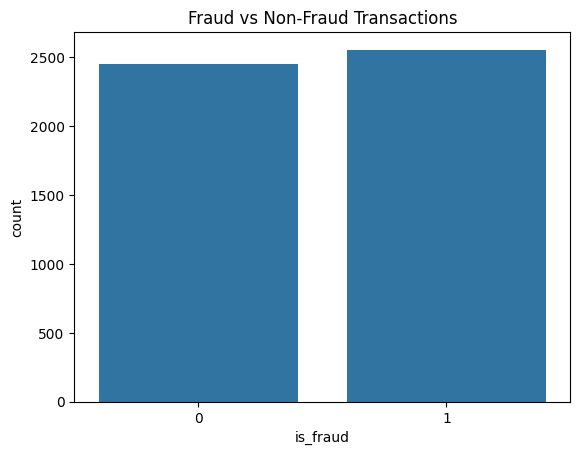

In [ ]:
sns.countplot(data=df, x='is_fraud')

plt.title('Fraud vs Non-Fraud Transactions')

plt.show()

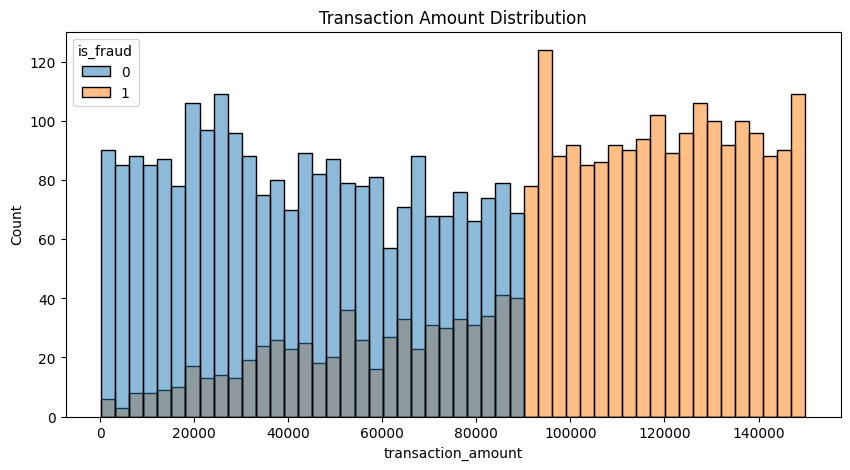

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='transaction_amount',
    hue='is_fraud',
    bins=50
)

plt.title('Transaction Amount Distribution')

plt.show()

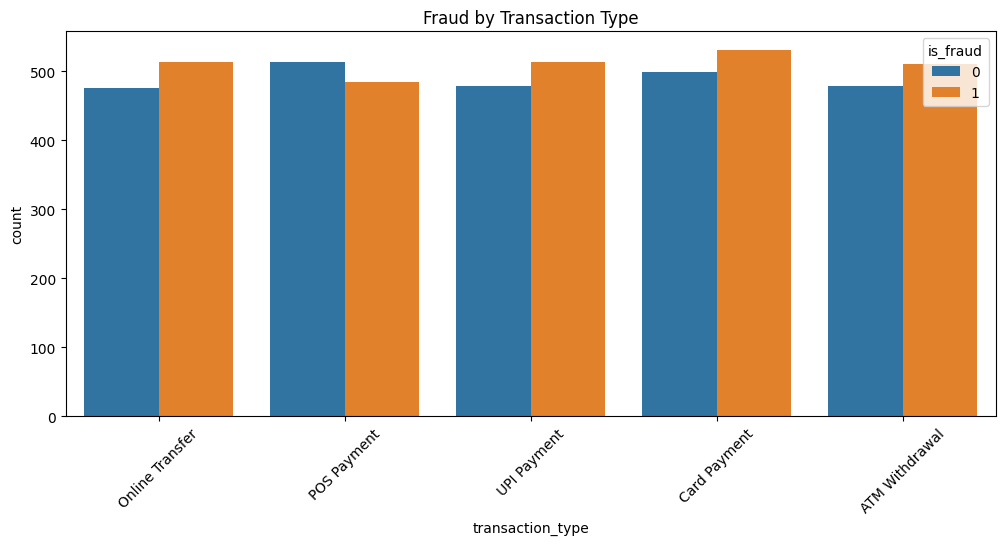

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='transaction_type',
    hue='is_fraud'
)

plt.xticks(rotation=45)

plt.title('Fraud by Transaction Type')

plt.show()

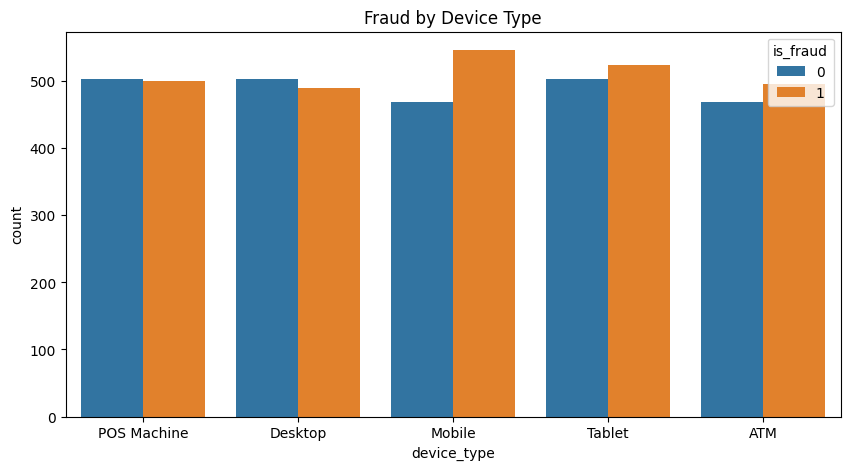

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='device_type',
    hue='is_fraud'
)

plt.title('Fraud by Device Type')

plt.show()

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    'transaction_type',
    'location',
    'device_type'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
X = df[[
    'transaction_amount',
    'transaction_type',
    'location',
    'device_type',
    'account_balance'
]]

y = df['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.962


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       497
           1       0.99      0.94      0.96       503

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



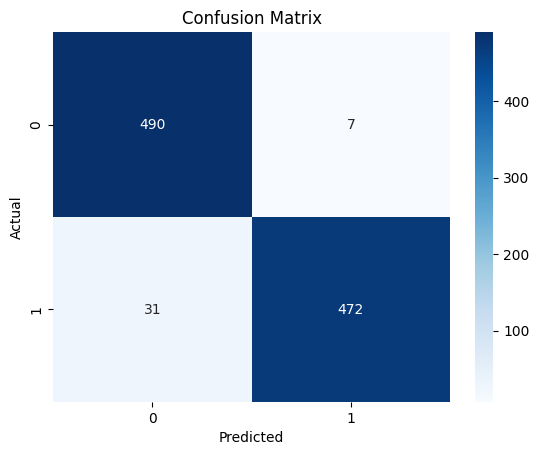

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,transaction_amount,0.731699
4,account_balance,0.225615
2,location,0.016006
3,device_type,0.013428
1,transaction_type,0.013253


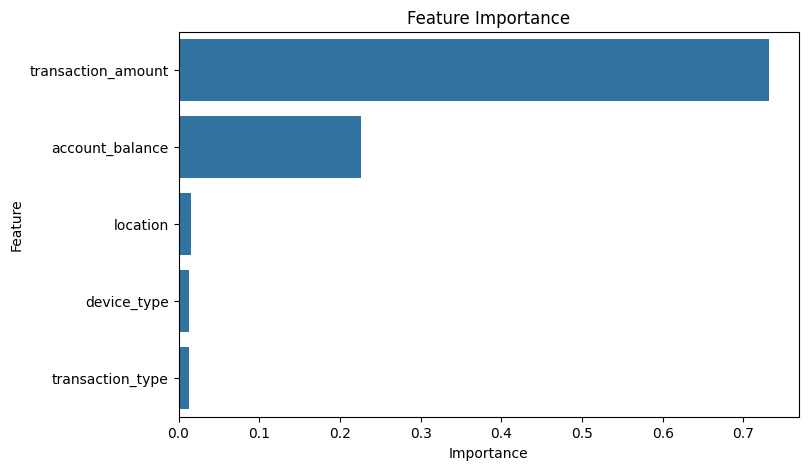

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

In [ ]:
!pip install imbalanced-learn xgboost

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('/content/banking_transactions.csv')
df.head()

,id,transaction_id,customer_id,transaction_amount,transaction_type,location,device_type,account_balance,transaction_time,is_fraud
0,1,b327f36d-5a4f-4b24-b5b4-75e7d6425a82,CUST1256,4168.01,Online Transfer,Hyderabad,POS Machine,68292.2,2026-04-08 03:09:27,0
1,2,f12c112e-00bf-42c7-a61e-e83f2f1b5384,CUST2264,101386.00,POS Payment,Pune,POS Machine,283040.0,2026-05-12 13:43:07,1
2,3,48aee92c-a309-4f1a-9cb3-60546ce55274,CUST8310,103761.00,UPI Payment,Mumbai,Desktop,214347.0,2026-05-16 08:44:39,1
3,4,ef1b1cbe-1f77-459d-b492-7a529a34159f,CUST8335,45710.80,Online Transfer,Delhi,Desktop,36276.6,2026-03-19 17:14:20,1
4,5,3e38eedc-8e26-4dd8-a329-d6c8348e6bf9,CUST5803,32569.90,Card Payment,Delhi,Mobile,105578.0,2026-05-18 08:56:04,0


In [ ]:
df_ml = df.copy()

encoder = LabelEncoder()

for col in ['transaction_type', 'location', 'device_type']:
    df_ml[col] = encoder.fit_transform(df_ml[col])

In [ ]:
X = df_ml[
    [
        'transaction_amount',
        'transaction_type',
        'location',
        'device_type',
        'account_balance'
    ]
]

y = df_ml['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

,count
is_fraud,
1,2043
0,2043


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.964
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       489
           1       0.99      0.94      0.96       511

    accuracy                           0.96      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.96      0.96      1000



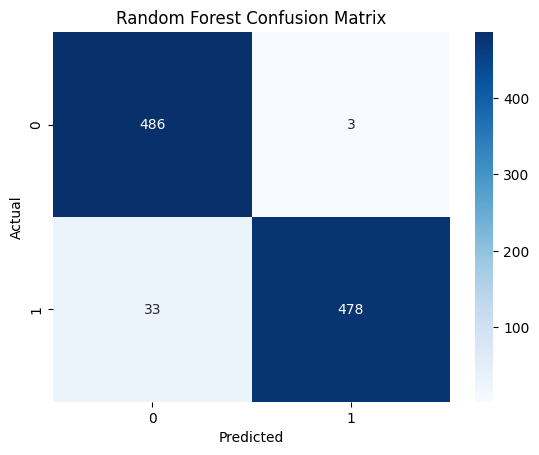

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()